# Processing: ERA5 Regional Mean Profiles for Libradtran

This notebook prepares seasonal climatological temperature and humidity profiles
for two regions — **tropics** (20°S–20°N) and **Arctic** (70°N–85°N) — from the
ARCO ERA5 reanalysis archive and saves them in the format expected by pyRadtran.

The output (`data/era5_region_profiles.nc`) can be loaded directly in
`lapse_rate_feedback.ipynb` to replace the single ARCO snapshot.

The workflow mirrors `sea_ice_era5.ipynb`: download a regional subset from Google
Cloud Storage, group by season, compute means, rename to pyRadtran conventions, save.

```{warning}
This notebook downloads ERA5 data from Google Cloud Storage.  The subset used
here (~2000–2020, two lat/lon boxes, 6-hourly, 64×128 grid) is manageable on a
laptop with ~8 GB RAM, but will take several minutes to load.  Use the Dask
cluster cell below if you want faster parallel loading.
```

## Setup

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import gcsfs
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_PATH = Path("data/era5_region_profiles.nc")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

## Load ARCO ERA5 (6-hourly, coarse resolution)

We use the 6-hourly 64×128 equiangular ARCO store — the same one used in
`sea_ice_era5.ipynb`.  It is much smaller than the high-resolution 1-hourly
store and sufficient for computing seasonal mean profiles.

In [2]:
gcs  = gcsfs.GCSFileSystem(token="anon")
path = "gs://gcp-public-data-arco-era5/ar/1959-2022-6h-128x64_equiangular_with_poles_conservative.zarr/"

full_era5 = xr.open_zarr(gcs.get_mapper(path), chunks="auto")
print(list(full_era5.data_vars))
full_era5

/home/josh/micromamba/envs/mamba_josh/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


['10m_u_component_of_wind', '10m_v_component_of_wind', '10m_wind_speed', '2m_temperature', 'angle_of_sub_gridscale_orography', 'anisotropy_of_sub_gridscale_orography', 'geopotential', 'geopotential_at_surface', 'high_vegetation_cover', 'lake_cover', 'lake_depth', 'land_sea_mask', 'low_vegetation_cover', 'mean_sea_level_pressure', 'sea_ice_cover', 'sea_surface_temperature', 'slope_of_sub_gridscale_orography', 'soil_type', 'specific_humidity', 'standard_deviation_of_filtered_subgrid_orography', 'standard_deviation_of_orography', 'surface_pressure', 'temperature', 'toa_incident_solar_radiation', 'toa_incident_solar_radiation_12hr', 'toa_incident_solar_radiation_24hr', 'toa_incident_solar_radiation_6hr', 'total_cloud_cover', 'total_column_water_vapour', 'total_precipitation_12hr', 'total_precipitation_24hr', 'total_precipitation_6hr', 'type_of_high_vegetation', 'type_of_low_vegetation', 'u_component_of_wind', 'v_component_of_wind', 'vertical_velocity', 'wind_speed']


<xarray.Dataset> Size: 326GB
Dimensions:                                           (time: 92040,
                                                       longitude: 128,
                                                       latitude: 64, level: 13)
Coordinates:
  * latitude                                          (latitude) float64 512B ...
  * level                                             (level) int64 104B 50 ....
  * longitude                                         (longitude) float64 1kB ...
  * time                                              (time) datetime64[ns] 736kB ...
Data variables: (12/38)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    angle_of_sub_gridscale_orography                  (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    anisotropy_of_sub_gridscale_orography             (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    ...                                                ...
    type_of_high_vegetation                           (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    type_of_low_vegetation                            (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    u_component_of_wind                               (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>
    v_component_of_wind                               (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>
    vertical_velocity                                 (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>

## Optional: Dask cluster for faster loading

Uncomment the cell below if you want to parallelise the data download.

In [3]:
# from dask.distributed import Client, LocalCluster
#
# cluster = LocalCluster(
#     n_workers=8,
#     threads_per_worker=1,
#     memory_limit="auto",
#     local_directory="/tmp/dask",
#     dashboard_address=":8787",
# )
# client = Client(cluster)
# print(client)

## Select regional subsets (2000–2020)

We restrict to 2000–2020 — long enough for a stable climatology, short enough
to stay manageable.  Pressure-level variables (`temperature`, `specific_humidity`,
`geopotential`) plus the surface variable `sea_surface_temperature` are kept.

In [4]:
VARS = ["temperature", "specific_humidity"]
if "geopotential" in full_era5.data_vars:
    VARS.append("geopotential")
if "sea_surface_temperature" in full_era5.data_vars:
    VARS.append("sea_surface_temperature")

print("Using variables:", VARS)

ds_time = full_era5[VARS].sel(time=slice("2000-01-01", "2020-12-31"))

Using variables: ['temperature', 'specific_humidity', 'geopotential', 'sea_surface_temperature']


In [5]:
# Latitude orientation: check whether it runs 90→-90 or -90→90
lats = full_era5.latitude.values
print(f"Latitude range: {lats.min():.1f} to {lats.max():.1f}")

# Tropics: 20°S to 20°N
ds_tropics = ds_time.sel(latitude=slice(
    min(-20.0, 20.0), max(-20.0, 20.0)
) if lats[0] < lats[-1] else slice(20.0, -20.0))

# Arctic: 70°N to 85°N
ds_arctic = ds_time.sel(latitude=slice(
    min(70.0, 85.0), max(70.0, 85.0)
) if lats[0] < lats[-1] else slice(85.0, 70.0))

print(f"Tropics lat: {ds_tropics.latitude.values[[0,-1]]}")
print(f"Arctic  lat: {ds_arctic.latitude.values[[0,-1]]}")

Latitude range: -90.0 to 90.0
Tropics lat: [-18.57142857  18.57142857]
Arctic  lat: [70.         84.28571429]


## Load into memory

We take the spatial mean over each region before loading so the in-memory
footprint is small: time × level only.

In [6]:
print("Computing tropical spatial mean...")
ds_tropics_mean = ds_tropics.mean(dim=["latitude", "longitude"]).load()
print("Computing Arctic spatial mean...")
ds_arctic_mean  = ds_arctic.mean(dim=["latitude", "longitude"]).load()
print("Done.")

Computing tropical spatial mean...
Computing Arctic spatial mean...
Done.


## Compute seasonal means

Group by calendar season (DJF, MAM, JJA, SON) and compute the mean profile.

In [7]:
SEASONS = ["DJF", "MAM", "JJA", "SON"]

def seasonal_mean(ds):
    """Return a Dataset with a new 'season' dimension (4 × level)."""
    parts = [ds.sel(time=(ds.time.dt.season == s)).mean("time") for s in SEASONS]
    return xr.concat(parts, dim=pd.Index(SEASONS, name="season"))


trp_seasonal = seasonal_mean(ds_tropics_mean)
arc_seasonal = seasonal_mean(ds_arctic_mean)

trp_seasonal

<xarray.Dataset> Size: 776B
Dimensions:                  (season: 4, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * season                   (season) object 32B 'DJF' 'MAM' 'JJA' 'SON'
Data variables:
    temperature              (season, level) float32 208B 204.3 192.5 ... 298.7
    specific_humidity        (season, level) float32 208B 2.671e-06 ... 0.0149
    geopotential             (season, level) float32 208B 2.014e+05 ... 1.014...
    sea_surface_temperature  (season) float32 16B 300.4 301.0 300.1 300.3

## Assemble output dataset

We rename variables and coordinates to match the pyRadtran ERA5 interface:
- `temperature` → `t` (units: K)
- `specific_humidity` → `q` (units: kg/kg)
- `geopotential` → `z` (units: m²/s²)
- `level` → `pressure_level` (units: hPa)

A `region` dimension is added for convenient downstream selection.

In [8]:
def rename_to_pyradtran(ds):
    rename_map = {
        "temperature":        "t",
        "specific_humidity":  "q",
        "level":              "pressure_level",
    }
    if "geopotential" in ds:
        rename_map["geopotential"] = "z"
    ds = ds.rename({k: v for k, v in rename_map.items() if k in ds or k in ds.coords})
    ds["t"].attrs["units"]              = "K"
    ds["q"].attrs["units"]              = "kg/kg"
    ds["pressure_level"].attrs["units"] = "hPa"
    if "z" in ds:
        ds["z"].attrs["units"]          = "m2/s2"
    return ds


trp_out = rename_to_pyradtran(trp_seasonal)
arc_out = rename_to_pyradtran(arc_seasonal)

# If no geopotential in the coarse store, add a dummy
if "z" not in trp_out:
    trp_out["z"] = xr.zeros_like(trp_out["t"]).assign_attrs(units="m2/s2")
    arc_out["z"] = xr.zeros_like(arc_out["t"]).assign_attrs(units="m2/s2")

# If no SST, use the near-surface temperature as proxy
if "sea_surface_temperature" not in trp_out:
    trp_out["sea_surface_temperature"] = trp_out["t"].isel(pressure_level=-1)
    arc_out["sea_surface_temperature"] = arc_out["t"].isel(pressure_level=-1)

ds_out = xr.concat(
    [trp_out, arc_out],
    dim=pd.Index(["tropics", "arctic"], name="region"),
)

ds_out

<xarray.Dataset> Size: 1kB
Dimensions:                  (region: 2, season: 4, pressure_level: 13)
Coordinates:
  * pressure_level           (pressure_level) int64 104B 50 100 150 ... 925 1000
  * season                   (season) object 32B 'DJF' 'MAM' 'JJA' 'SON'
  * region                   (region) object 16B 'tropics' 'arctic'
Data variables:
    t                        (region, season, pressure_level) float32 416B 20...
    q                        (region, season, pressure_level) float32 416B 2....
    z                        (region, season, pressure_level) float32 416B 2....
    sea_surface_temperature  (region, season) float32 32B 300.4 301.0 ... 272.9

## Save to netCDF

In [9]:
ds_out.to_netcdf(OUTPUT_PATH)
print(f"Saved: {OUTPUT_PATH}")

Saved: data/era5_region_profiles.nc


## Quick verification

Check that the profiles look physically reasonable.

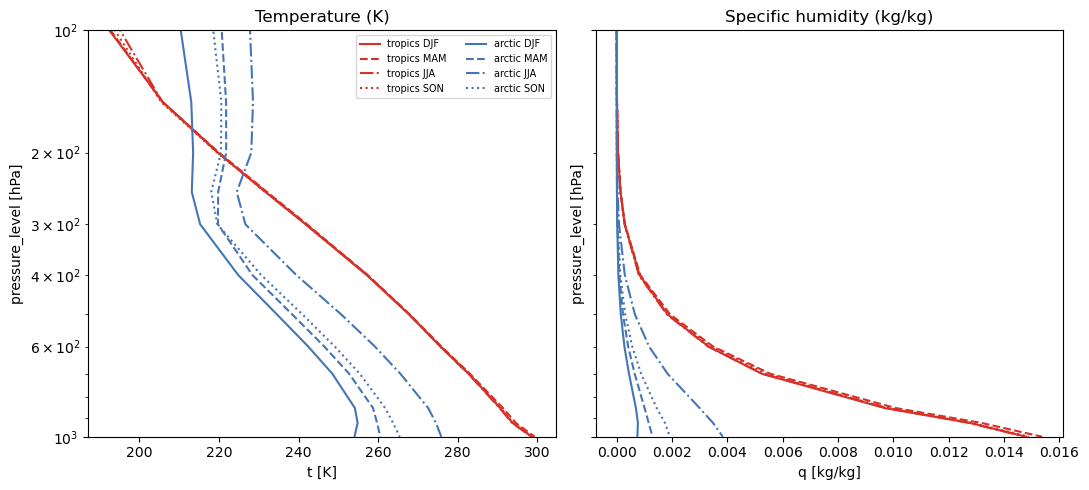

In [10]:
ds_check = xr.open_dataset(OUTPUT_PATH)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for region, color in [("tropics", "#d73027"), ("arctic", "#4575b4")]:
    for season, ls in zip(SEASONS, ["-", "--", "-.", ":"]):
        ds_check["t"].sel(region=region, season=season).plot(
            y="pressure_level",
            yincrease=False,
            ax=axes[0],
            color=color,
            ls=ls,
            label=f"{region} {season}",
        )
        ds_check["q"].sel(region=region, season=season).plot(
            y="pressure_level",
            yincrease=False,
            ax=axes[1],
            color=color,
            ls=ls,
            label=f"{region} {season}",
        )

for ax in axes:
    ax.set_yscale("log")
    ax.set_ylim(1000, 100)

axes[0].set_title("Temperature (K)")
axes[1].set_title("Specific humidity (kg/kg)")
axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout()